In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [30]:
df = pd.read_csv("../data/sustainable_concrete_dataset.csv", low_memory=True)
df.head(2)

,cement,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,embodied_CO2,energy_consumption,resource_consumption
0,312.362036,162.959305,7.851171,1001.810898,771.598763,51,344.476684,307.856482,1628.413117,2256.582173
1,485.214292,187.933066,7.409364,1039.004419,841.629699,71,374.295933,468.240201,2418.001368,2561.190840


In [31]:
# analised

In [32]:
df.isnull().sum()

cement                  0
water                   0
superplasticizer        0
coarse_aggregate        0
fine_aggregate          0
age                     0
compressive_strength    0
embodied_CO2            0
energy_consumption      0
resource_consumption    0
dtype: int64

In [33]:
corr = df.corr(numeric_only=True)
corr

,cement,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,embodied_CO2,energy_consumption,resource_consumption
cement,1.000000,0.029310,0.014518,-0.029424,0.034785,-0.035118,0.229012,0.987426,0.929188,0.591119
water,0.029310,1.000000,0.027262,-0.005791,0.032911,-0.039491,0.053373,0.033279,0.037486,0.170312
superplasticizer,0.014518,0.027262,1.000000,-0.013560,-0.008858,0.052574,-0.038008,0.172333,0.382992,0.057378
coarse_aggregate,-0.029424,-0.005791,-0.013560,1.000000,-0.044812,-0.031235,0.114419,-0.027070,-0.026466,0.527532
fine_aggregate,0.034785,0.032911,-0.008858,-0.044812,1.000000,0.046623,-0.037013,0.034764,0.032547,0.571187
age,-0.035118,-0.039491,0.052574,-0.031235,0.046623,1.000000,-0.900516,-0.026320,-0.013017,-0.013974
compressive_strength,0.229012,0.053373,-0.038008,0.114419,-0.037013,-0.900516,1.000000,0.220010,0.198064,0.182865
embodied_CO2,0.987426,0.033279,0.172333,-0.027070,0.034764,-0.026320,0.220010,1.000000,0.975929,0.594819
energy_consumption,0.929188,0.037486,0.382992,-0.026466,0.032547,-0.013017,0.198064,0.975929,1.000000,0.572728
resource_consumption,0.591119,0.170312,0.057378,0.527532,0.571187,-0.013974,0.182865,0.594819,0.572728,1.000000


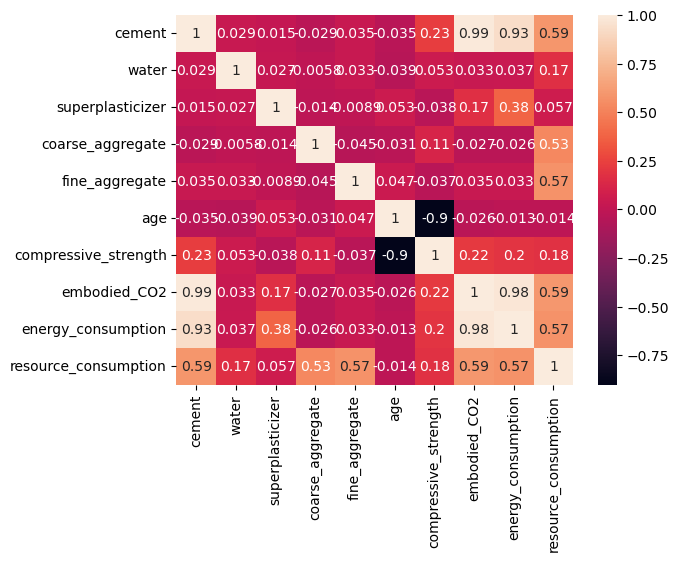

In [34]:
plt.figure()
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

In [35]:
corr = df.corr(numeric_only=True)
corr[corr.abs() > 0.5]

,cement,water,superplasticizer,coarse_aggregate,fine_aggregate,age,compressive_strength,embodied_CO2,energy_consumption,resource_consumption
cement,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.987426,0.929188,0.591119
water,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
superplasticizer,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
coarse_aggregate,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,0.527532
fine_aggregate,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,0.571187
age,NaN,NaN,NaN,NaN,NaN,1.000000,-0.900516,NaN,NaN,NaN
compressive_strength,NaN,NaN,NaN,NaN,NaN,-0.900516,1.000000,NaN,NaN,NaN
embodied_CO2,0.987426,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,0.975929,0.594819
energy_consumption,0.929188,NaN,NaN,NaN,NaN,NaN,NaN,0.975929,1.000000,0.572728
resource_consumption,0.591119,NaN,NaN,0.527532,0.571187,NaN,NaN,0.594819,0.572728,1.000000


In [36]:
df.corr(numeric_only=True)["compressive_strength"].sort_values(ascending=False)


compressive_strength    1.000000
cement                  0.229012
embodied_CO2            0.220010
energy_consumption      0.198064
resource_consumption    0.182865
coarse_aggregate        0.114419
water                   0.053373
fine_aggregate         -0.037013
superplasticizer       -0.038008
age                    -0.900516
Name: compressive_strength, dtype: float64

In [37]:
df.corr(numeric_only=True)["energy_consumption"].sort_values(ascending=False)


energy_consumption      1.000000
embodied_CO2            0.975929
cement                  0.929188
resource_consumption    0.572728
superplasticizer        0.382992
compressive_strength    0.198064
water                   0.037486
fine_aggregate          0.032547
age                    -0.013017
coarse_aggregate       -0.026466
Name: energy_consumption, dtype: float64

In [38]:
df.corr(numeric_only=True)["embodied_CO2"].sort_values(ascending=False)


embodied_CO2            1.000000
cement                  0.987426
energy_consumption      0.975929
resource_consumption    0.594819
compressive_strength    0.220010
superplasticizer        0.172333
fine_aggregate          0.034764
water                   0.033279
age                    -0.026320
coarse_aggregate       -0.027070
Name: embodied_CO2, dtype: float64

In [39]:
df.corr(numeric_only=True)["resource_consumption"].sort_values(ascending=False)


resource_consumption    1.000000
embodied_CO2            0.594819
cement                  0.591119
energy_consumption      0.572728
fine_aggregate          0.571187
coarse_aggregate        0.527532
compressive_strength    0.182865
water                   0.170312
superplasticizer        0.057378
age                    -0.013974
Name: resource_consumption, dtype: float64

In [49]:
labels = ['compressive_strength', 'resource_consumption', 'embodied_CO2', 'energy_consumption']

features = df.drop( columns=labels)

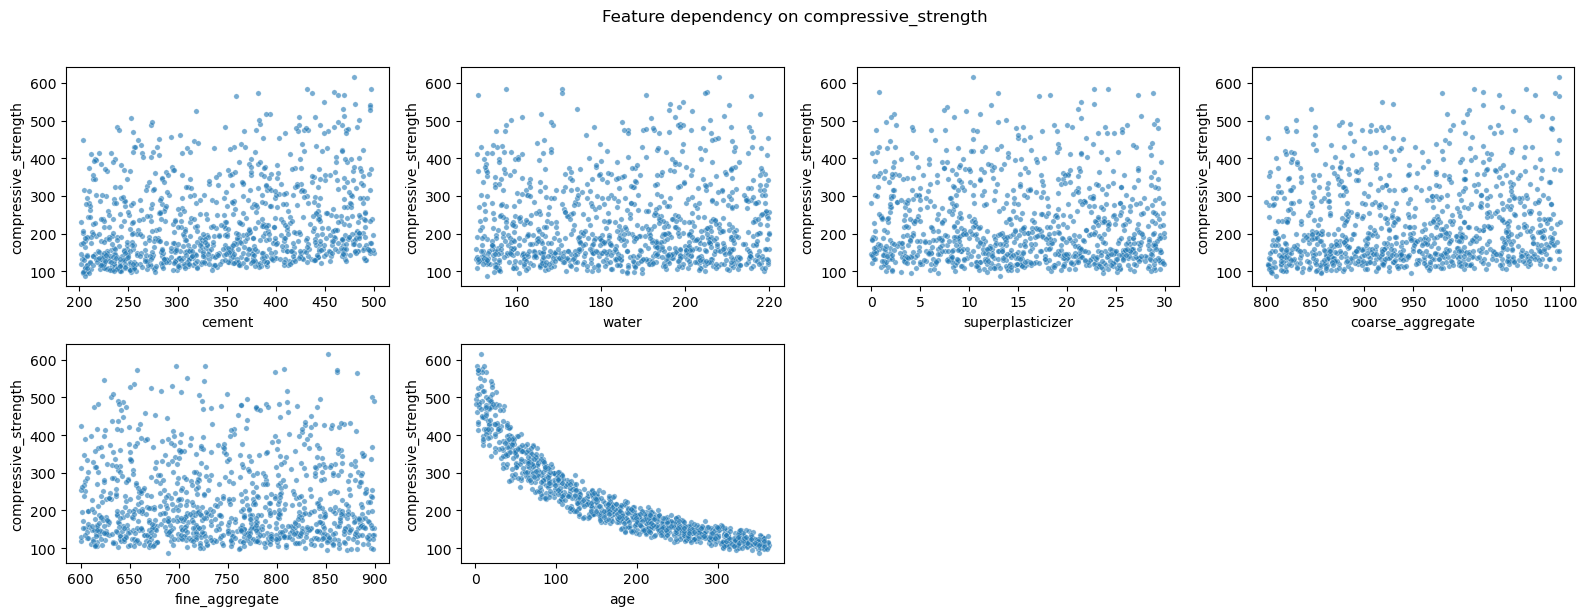

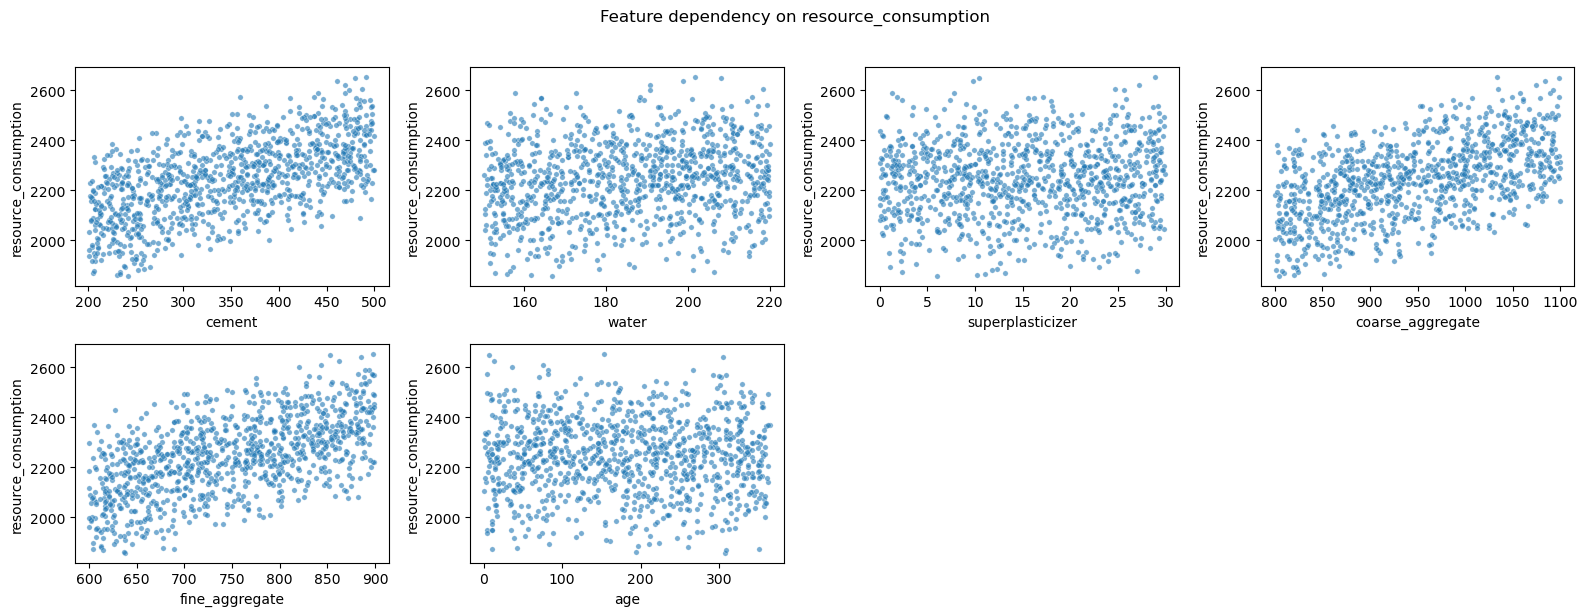

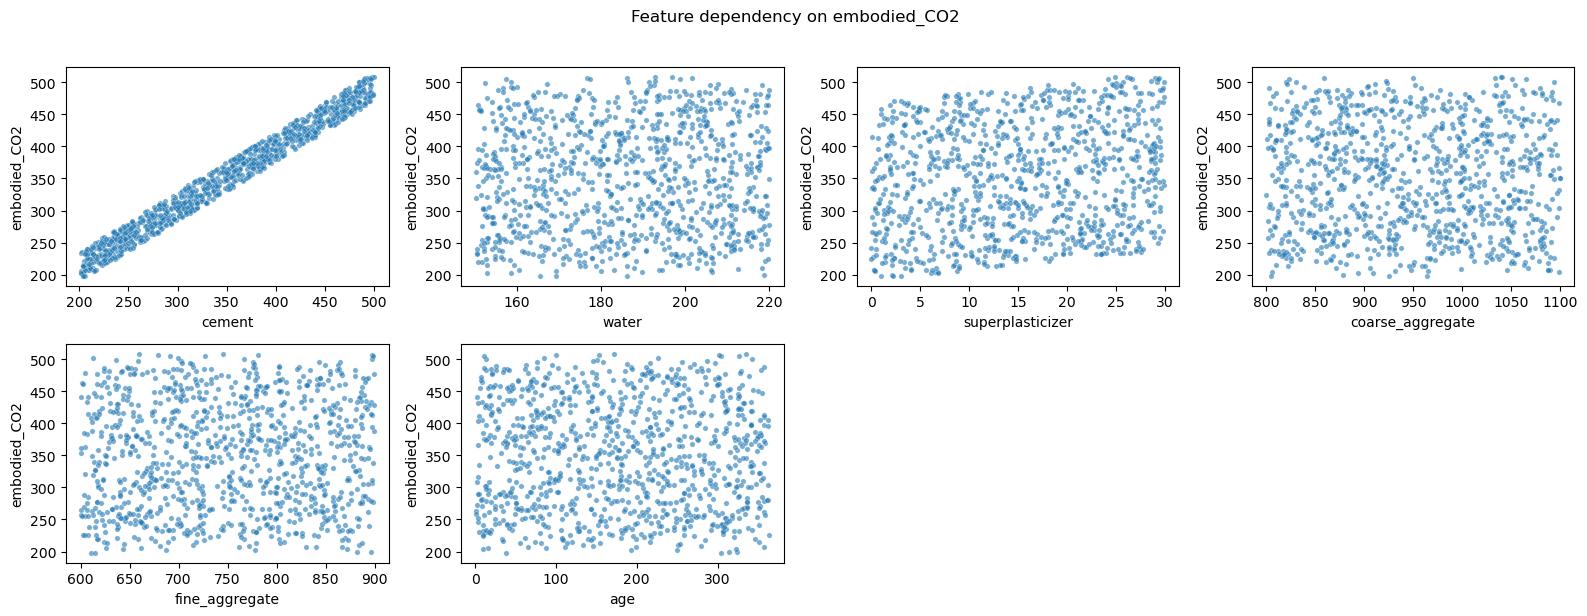

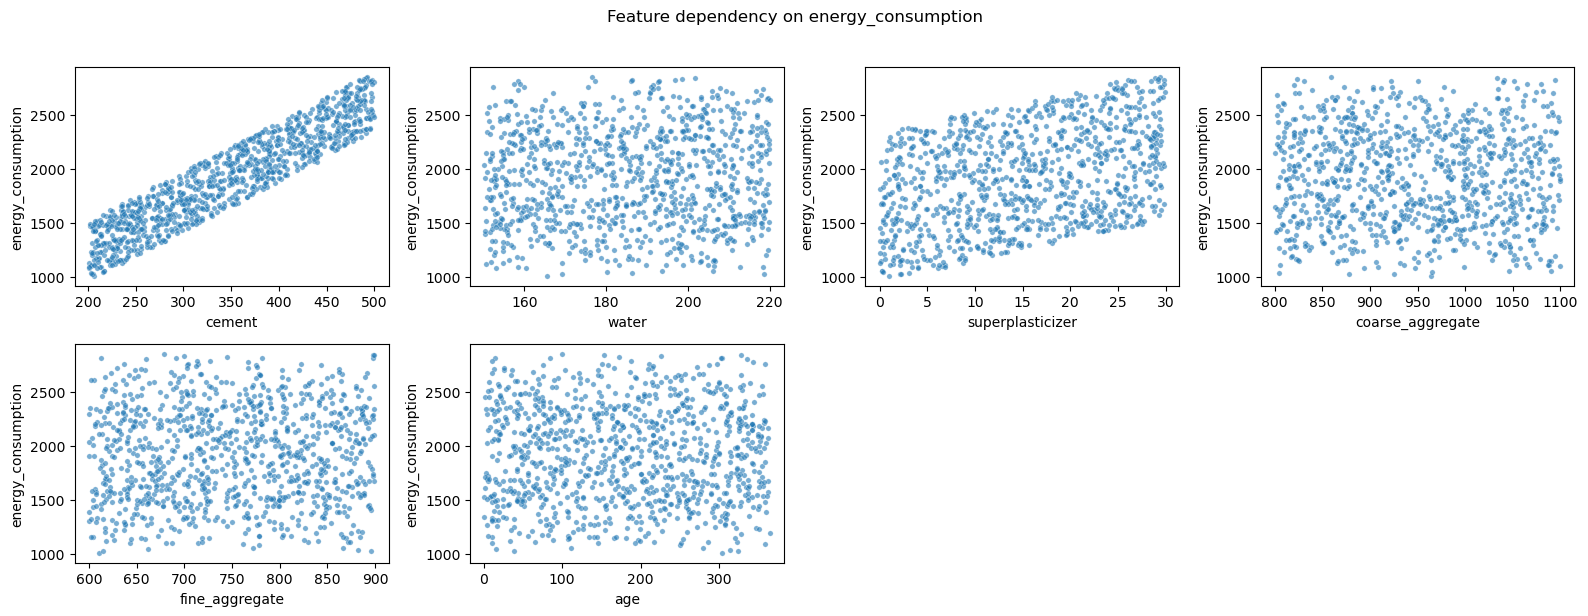

In [51]:
n_cols = 4

for target in labels:
    n_rows = math.ceil(len(features.columns) / n_cols)
    
    plt.figure(figsize=(4 * n_cols, 3 * n_rows))
    
    for i, col in enumerate(features.columns, 1):
        plt.subplot(n_rows, n_cols, i)
        sns.scatterplot(
            data=df,
            x=col,
            y=target,
            s=15,
            alpha=0.6
        )
        plt.xlabel(col)
        plt.ylabel(target)
    
    plt.suptitle(f"Feature dependency on {target}", y=1.02)
    plt.tight_layout()
    plt.show()

In [40]:
# preprocessing